# Copa Mundial de Fútbol 2022 · Análisis de datos

**Competición:** Copa Mundial (`league = 1`)  
**Temporada:** 2022  
**Elaborado por:** emanuel

Este notebook responde las preguntas del taller **exclusivamente a partir de**
`equipos.parquet`, `partidos.parquet` y `clasificacion.parquet`. No realiza
ninguna solicitud a la API.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", context="notebook")
COLORES = ["#7c3aed", "#2563eb", "#0891b2", "#059669", "#d97706", "#dc2626"]
sns.set_palette(COLORES)

BASE = Path.cwd()
if not (BASE / "equipos.parquet").exists():
    BASE = Path(".").resolve()

archivos = {
    "equipos": BASE / "equipos.parquet",
    "partidos": BASE / "partidos.parquet",
    "clasificacion": BASE / "clasificacion.parquet",
}
faltantes = [ruta.name for ruta in archivos.values() if not ruta.exists()]
assert not faltantes, f"Faltan archivos Parquet: {faltantes}"
print("Fuente de datos: tres archivos Parquet locales.")

Fuente de datos: tres archivos Parquet locales.


## 1. Carga y panorama general

In [2]:
equipos = pd.read_parquet(archivos["equipos"])
partidos = pd.read_parquet(archivos["partidos"])
clasificacion = pd.read_parquet(archivos["clasificacion"])

resumen_archivos = pd.DataFrame(
    [
        {"archivo": "equipos.parquet", "filas": len(equipos), "columnas": equipos.shape[1]},
        {"archivo": "partidos.parquet", "filas": len(partidos), "columnas": partidos.shape[1]},
        {"archivo": "clasificacion.parquet", "filas": len(clasificacion), "columnas": clasificacion.shape[1]},
    ]
)
display(resumen_archivos.style.hide(axis="index").set_caption("Dimensiones de los archivos"))

archivo,filas,columnas
equipos.parquet,32,12
partidos.parquet,64,26
clasificacion.parquet,32,21


In [3]:
esquemas = []
for nombre, df in {
    "equipos.parquet": equipos,
    "partidos.parquet": partidos,
    "clasificacion.parquet": clasificacion,
}.items():
    esquemas.extend(
        {"archivo": nombre, "columna": columna, "tipo": str(tipo)}
        for columna, tipo in df.dtypes.items()
    )
display(pd.DataFrame(esquemas).style.hide(axis="index").set_caption("Tipos de datos almacenados"))

archivo,columna,tipo
equipos.parquet,equipo_id,Int64
equipos.parquet,nombre_equipo,string
equipos.parquet,codigo_equipo,string
equipos.parquet,pais,string
equipos.parquet,anio_fundacion,Int64
equipos.parquet,es_seleccion_nacional,boolean
equipos.parquet,logo_url,string
equipos.parquet,competencia_id,Int64
equipos.parquet,temporada,Int64
equipos.parquet,fecha_extraccion,"datetime64[us, UTC]"


## 2. ¿Cuántos equipos participaron en la competición?

In [4]:
cantidad_equipos = equipos["equipo_id"].nunique()
display(Markdown(f"### Resultado: **{cantidad_equipos} equipos** participaron en la competición."))

### Resultado: **32 equipos** participaron en la competición.

## 3. ¿Cuántos partidos se jugaron en cada ronda?

ronda,cantidad_partidos
Group Stage - 2,16
Group Stage - 1,16
Group Stage - 3,16
Round of 16,8
Quarter-finals,4
Semi-finals,2
3rd Place Final,1
Final,1


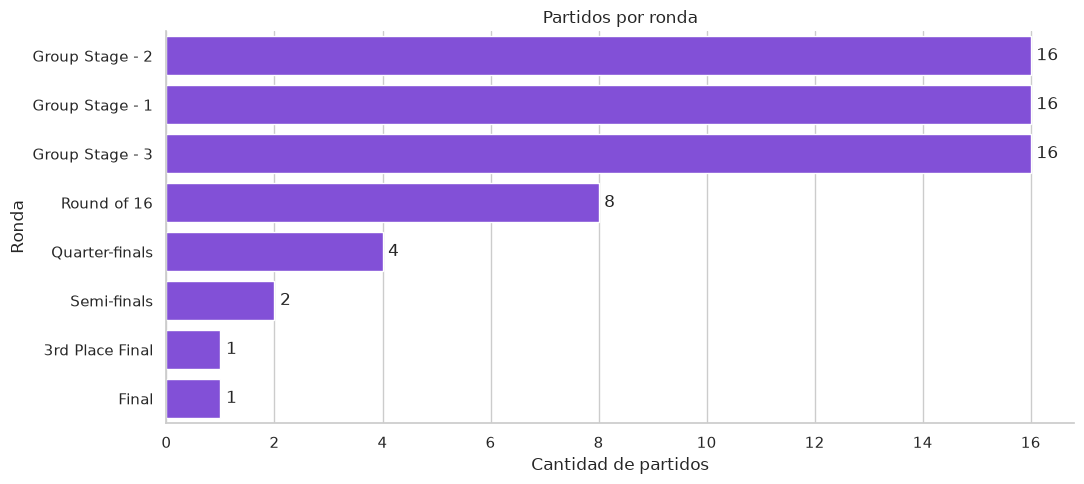

In [5]:
partidos_por_ronda = (
    partidos.groupby("ronda", dropna=False)
    .size()
    .rename("cantidad_partidos")
    .sort_values(ascending=False)
    .reset_index()
)
display(partidos_por_ronda.style.hide(axis="index").set_caption("Partidos disputados por ronda"))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=partidos_por_ronda, x="cantidad_partidos", y="ronda", color=COLORES[0], ax=ax)
ax.set(title="Partidos por ronda", xlabel="Cantidad de partidos", ylabel="Ronda")
ax.bar_label(ax.containers[0], padding=4)
sns.despine()
plt.tight_layout()
plt.show()

## 4. ¿Cuál fue el partido con mayor cantidad total de goles?

In [6]:
partidos_goles = partidos.assign(
    total_goles=partidos["goles_local"].fillna(0) + partidos["goles_visitante"].fillna(0)
)
maximo_goles = partidos_goles["total_goles"].max()
partidos_maximo_goles = partidos_goles.loc[
    partidos_goles["total_goles"].eq(maximo_goles),
    ["partido_id", "ronda", "equipo_local_nombre", "goles_local",
     "goles_visitante", "equipo_visitante_nombre", "total_goles"],
].sort_values("partido_id")
display(Markdown(f"### Resultado: el máximo fue de **{int(maximo_goles)} goles**."))
display(partidos_maximo_goles.style.hide(axis="index"))

### Resultado: el máximo fue de **8 goles**.

partido_id,ronda,equipo_local_nombre,goles_local,goles_visitante,equipo_visitante_nombre,total_goles
855735,Group Stage - 1,England,6,2,Iran,8


## 5. ¿Cuál fue el equipo que anotó más goles?

### Resultado: máximo de **16 goles**.

equipo_id,nombre_equipo,total_goles
2,France,16


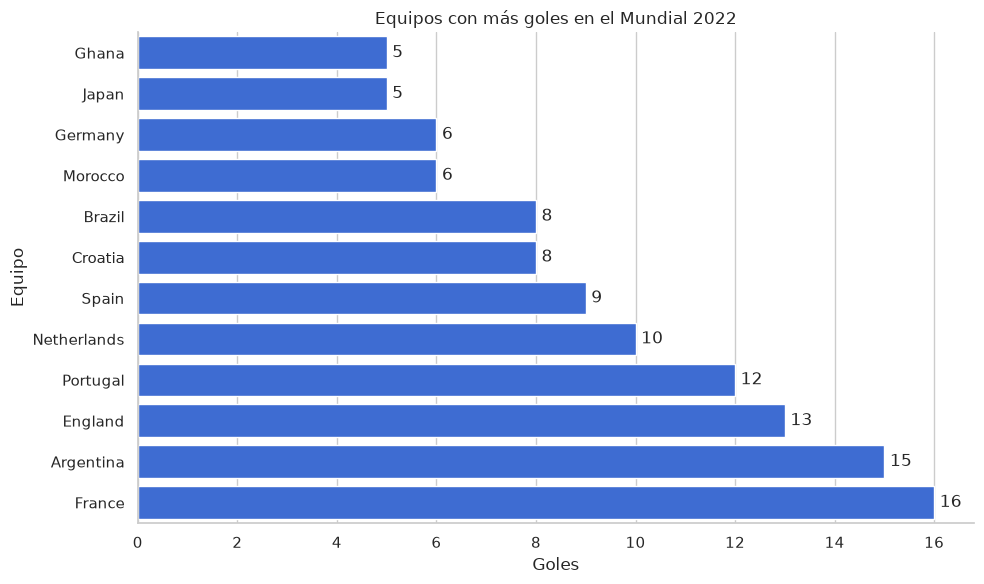

In [7]:
goles_local = partidos[["equipo_local_id", "equipo_local_nombre", "goles_local"]].rename(
    columns={"equipo_local_id": "equipo_id", "equipo_local_nombre": "nombre_equipo", "goles_local": "goles"}
)
goles_visitante = partidos[["equipo_visitante_id", "equipo_visitante_nombre", "goles_visitante"]].rename(
    columns={"equipo_visitante_id": "equipo_id", "equipo_visitante_nombre": "nombre_equipo", "goles_visitante": "goles"}
)
goles_por_equipo = (
    pd.concat([goles_local, goles_visitante], ignore_index=True)
    .groupby(["equipo_id", "nombre_equipo"], as_index=False)["goles"]
    .sum()
    .rename(columns={"goles": "total_goles"})
    .sort_values(["total_goles", "nombre_equipo"], ascending=[False, True])
)
maximo_equipo_goles = goles_por_equipo["total_goles"].max()
lideres_goles = goles_por_equipo[goles_por_equipo["total_goles"].eq(maximo_equipo_goles)]
display(Markdown(f"### Resultado: máximo de **{int(maximo_equipo_goles)} goles**."))
display(lideres_goles.style.hide(axis="index"))

top_goleadores = goles_por_equipo.head(12).sort_values("total_goles")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_goleadores, x="total_goles", y="nombre_equipo", color=COLORES[1], ax=ax)
ax.set(title="Equipos con más goles en el Mundial 2022", xlabel="Goles", ylabel="Equipo")
ax.bar_label(ax.containers[0], padding=4)
sns.despine()
plt.tight_layout()
plt.show()

## 6. ¿Cuál fue el equipo que ganó más partidos?

### Resultado: máximo de **6 victorias**.

equipo_id,nombre_equipo,victorias
26,Argentina,6


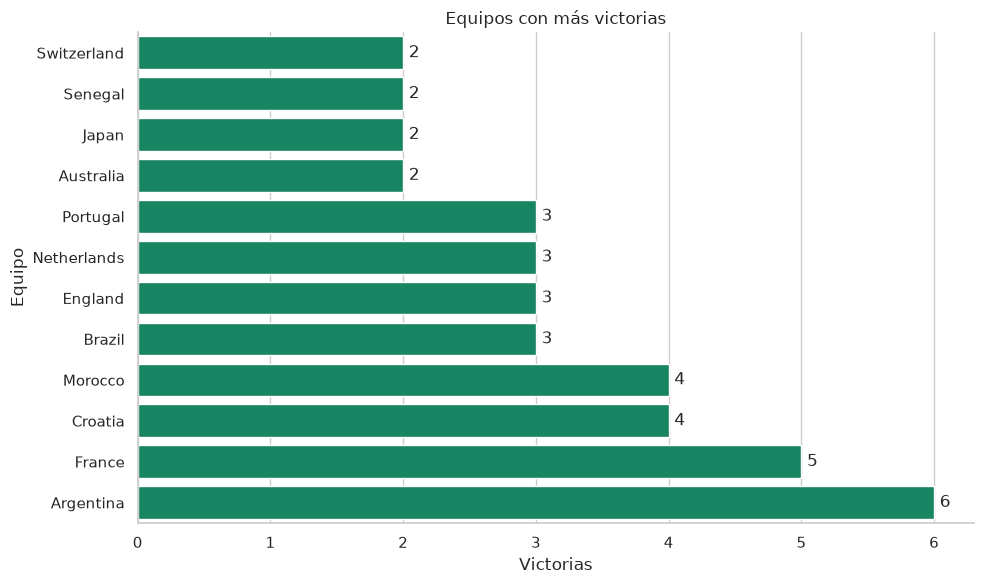

In [8]:
victorias_local = partidos.loc[
    partidos["gano_local"].fillna(False), ["equipo_local_id", "equipo_local_nombre"]
].rename(columns={"equipo_local_id": "equipo_id", "equipo_local_nombre": "nombre_equipo"})
victorias_visitante = partidos.loc[
    partidos["gano_visitante"].fillna(False), ["equipo_visitante_id", "equipo_visitante_nombre"]
].rename(columns={"equipo_visitante_id": "equipo_id", "equipo_visitante_nombre": "nombre_equipo"})
victorias_por_equipo = (
    pd.concat([victorias_local, victorias_visitante], ignore_index=True)
    .value_counts(["equipo_id", "nombre_equipo"])
    .rename("victorias")
    .reset_index()
    .sort_values(["victorias", "nombre_equipo"], ascending=[False, True])
)
maximo_victorias = victorias_por_equipo["victorias"].max()
lideres_victorias = victorias_por_equipo[victorias_por_equipo["victorias"].eq(maximo_victorias)]
display(Markdown(f"### Resultado: máximo de **{int(maximo_victorias)} victorias**."))
display(lideres_victorias.style.hide(axis="index"))

top_victorias = victorias_por_equipo.head(12).sort_values("victorias")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_victorias, x="victorias", y="nombre_equipo", color=COLORES[3], ax=ax)
ax.set(title="Equipos con más victorias", xlabel="Victorias", ylabel="Equipo")
ax.bar_label(ax.containers[0], padding=4)
sns.despine()
plt.tight_layout()
plt.show()

## 7. ¿Cuál fue la mejor diferencia de gol dentro de cada grupo?

grupo,equipo_id,nombre_equipo,diferencia_gol
Group A,1118,Netherlands,4
Group B,10,England,7
Group C,26,Argentina,3
Group D,2,France,3
Group E,9,Spain,6
Group F,3,Croatia,3
Group F,31,Morocco,3
Group G,6,Brazil,2
Group H,27,Portugal,2


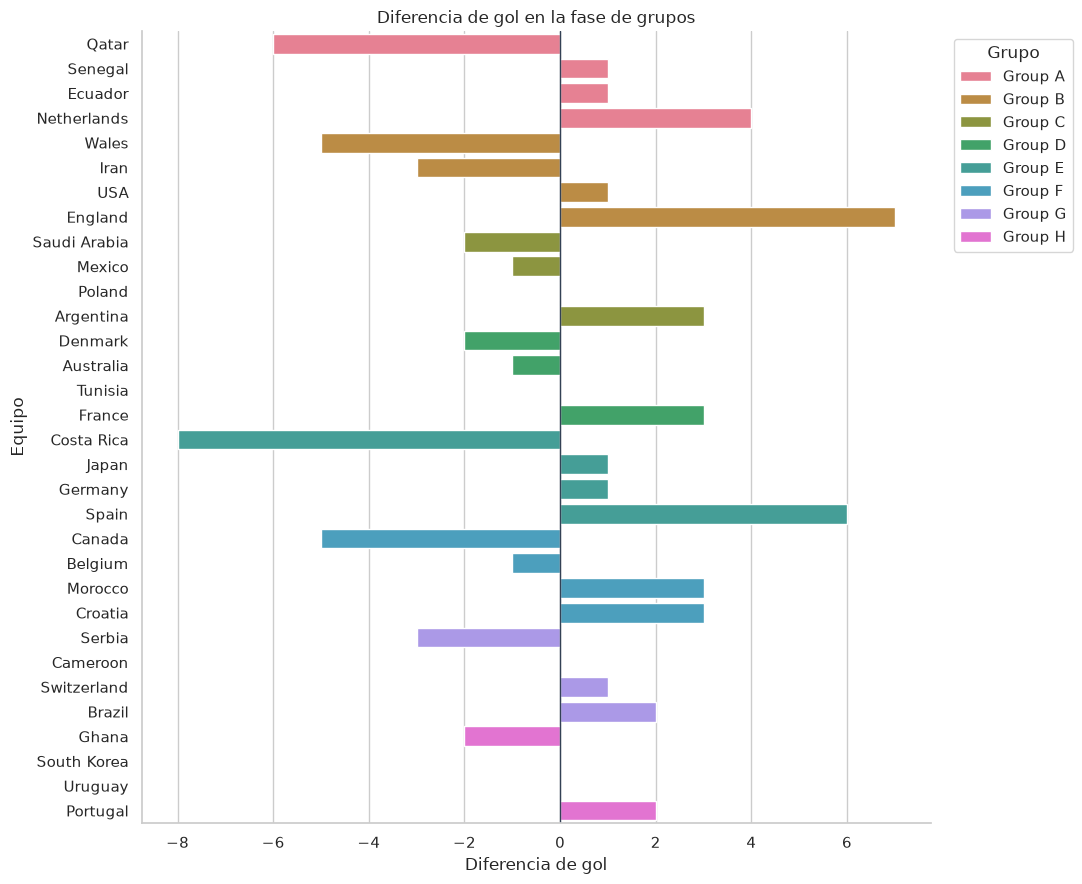

In [9]:
maxima_diferencia_grupo = clasificacion.groupby("grupo")["diferencia_gol"].transform("max")
mejor_diferencia_por_grupo = clasificacion.loc[
    clasificacion["diferencia_gol"].eq(maxima_diferencia_grupo),
    ["grupo", "equipo_id", "nombre_equipo", "diferencia_gol"],
].sort_values(["grupo", "nombre_equipo"])
display(mejor_diferencia_por_grupo.style.hide(axis="index").set_caption("Mejor diferencia de gol por grupo"))

orden = clasificacion.sort_values(["grupo", "diferencia_gol"])["nombre_equipo"]
fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(
    data=clasificacion,
    x="diferencia_gol",
    y="nombre_equipo",
    hue="grupo",
    order=orden,
    dodge=False,
    ax=ax,
)
ax.axvline(0, color="#334155", linewidth=1)
ax.set(title="Diferencia de gol en la fase de grupos", xlabel="Diferencia de gol", ylabel="Equipo")
ax.legend(title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

## 8. ¿Qué equipos terminaron primeros en cada grupo?

In [10]:
primeros_grupo = clasificacion.loc[
    clasificacion["posicion"].eq(1),
    ["grupo", "posicion", "equipo_id", "nombre_equipo", "puntos", "diferencia_gol"],
].sort_values("grupo")
display(primeros_grupo.style.hide(axis="index").set_caption("Primer lugar de cada grupo"))

grupo,posicion,equipo_id,nombre_equipo,puntos,diferencia_gol
Group A,1,1118,Netherlands,7,4
Group B,1,10,England,7,7
Group C,1,26,Argentina,6,3
Group D,1,2,France,6,3
Group E,1,12,Japan,6,1
Group F,1,31,Morocco,7,3
Group G,1,6,Brazil,6,2
Group H,1,27,Portugal,6,2


## 9. ¿Cuál fue el estadio con más partidos?

### Resultado: máximo de **10 partidos** en un estadio.

estadio_id,estadio_nombre,estadio_ciudad,cantidad_partidos
,Lusail Iconic Stadium,Lusail,10


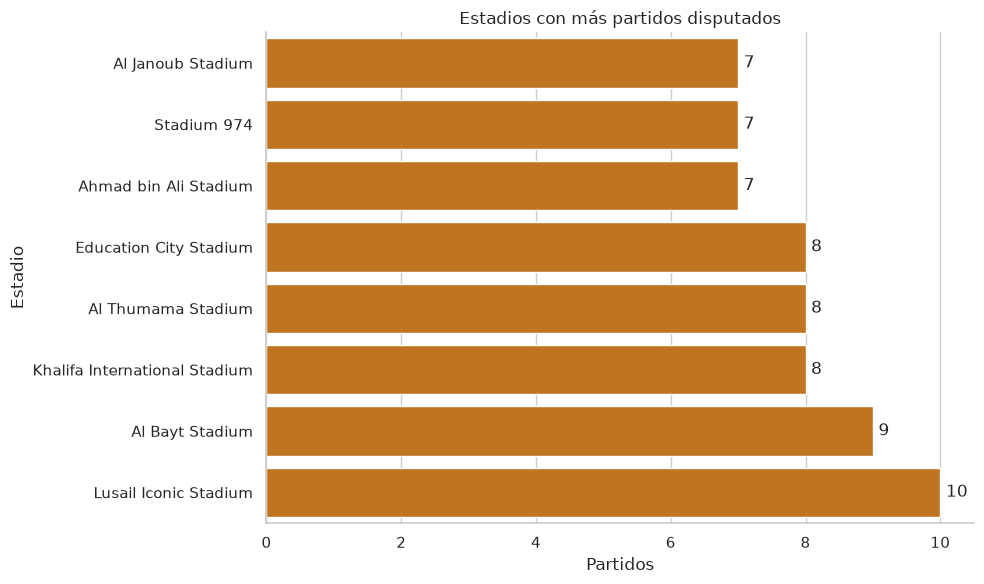

In [11]:
partidos_por_estadio = (
    partidos.groupby(["estadio_id", "estadio_nombre", "estadio_ciudad"], dropna=False)
    .size()
    .rename("cantidad_partidos")
    .reset_index()
    .sort_values(["cantidad_partidos", "estadio_nombre"], ascending=[False, True])
)
maximo_estadio = partidos_por_estadio["cantidad_partidos"].max()
estadios_lideres = partidos_por_estadio[partidos_por_estadio["cantidad_partidos"].eq(maximo_estadio)]
display(Markdown(f"### Resultado: máximo de **{int(maximo_estadio)} partidos** en un estadio."))
display(estadios_lideres.style.hide(axis="index"))

grafica_estadios = partidos_por_estadio.head(10).sort_values("cantidad_partidos")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=grafica_estadios, x="cantidad_partidos", y="estadio_nombre", color=COLORES[4], ax=ax)
ax.set(title="Estadios con más partidos disputados", xlabel="Partidos", ylabel="Estadio")
ax.bar_label(ax.containers[0], padding=4)
sns.despine()
plt.tight_layout()
plt.show()

## 10. ¿Existen partidos duplicados según `partido_id`?

In [12]:
duplicados_partido = partidos[partidos.duplicated(subset=["partido_id"], keep=False)]
cantidad_duplicados = partidos.duplicated(subset=["partido_id"]).sum()
respuesta_duplicados = "Sí" if cantidad_duplicados else "No"
display(Markdown(
    f"### Resultado: **{respuesta_duplicados}**. "
    f"Se encontraron **{int(cantidad_duplicados)} registros duplicados** por `partido_id`."
))
if not duplicados_partido.empty:
    display(duplicados_partido.sort_values("partido_id"))

### Resultado: **No**. Se encontraron **0 registros duplicados** por `partido_id`.

## 11. ¿Cuántos valores nulos tiene cada columna de cada archivo?

### equipos.parquet

columna,valores_nulos,porcentaje_nulos
equipo_id,0,0.000000
nombre_equipo,0,0.000000
codigo_equipo,0,0.000000
pais,0,0.000000
anio_fundacion,0,0.000000
es_seleccion_nacional,0,0.000000
logo_url,0,0.000000
competencia_id,0,0.000000
temporada,0,0.000000
fecha_extraccion,0,0.000000


### partidos.parquet

columna,valores_nulos,porcentaje_nulos
partido_id,0,0.000000
competencia_id,0,0.000000
competencia_nombre,0,0.000000
temporada,0,0.000000
ronda,0,0.000000
fecha_partido,0,0.000000
zona_horaria,0,0.000000
estado_partido,0,0.000000
minuto_transcurrido,0,0.000000
arbitro,0,0.000000


### clasificacion.parquet

columna,valores_nulos,porcentaje_nulos
grupo,0,0.000000
posicion,0,0.000000
equipo_id,0,0.000000
nombre_equipo,0,0.000000
puntos,0,0.000000
partidos_jugados,0,0.000000
partidos_ganados,0,0.000000
partidos_empatados,0,0.000000
partidos_perdidos,0,0.000000
goles_favor,0,0.000000


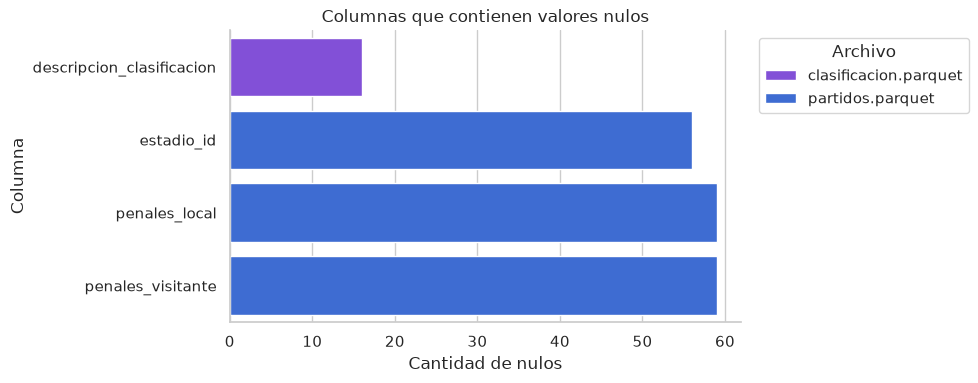

In [13]:
dataframes = {
    "equipos.parquet": equipos,
    "partidos.parquet": partidos,
    "clasificacion.parquet": clasificacion,
}
nulos = pd.concat(
    [
        df.isna().sum().rename("valores_nulos").to_frame().assign(archivo=nombre)
        for nombre, df in dataframes.items()
    ]
).reset_index(names="columna")[["archivo", "columna", "valores_nulos"]]
nulos["porcentaje_nulos"] = nulos.apply(
    lambda fila: fila["valores_nulos"] / len(dataframes[fila["archivo"]]) * 100,
    axis=1,
)
nulos["porcentaje_nulos"] = nulos["porcentaje_nulos"].round(2)

for nombre in dataframes:
    display(Markdown(f"### {nombre}"))
    display(
        nulos[nulos["archivo"].eq(nombre)][["columna", "valores_nulos", "porcentaje_nulos"]]
        .style.hide(axis="index")
    )

nulos_positivos = nulos[nulos["valores_nulos"].gt(0)].sort_values("valores_nulos")
if not nulos_positivos.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nulos_positivos) * 0.38)))
    sns.barplot(
        data=nulos_positivos,
        x="valores_nulos",
        y="columna",
        hue="archivo",
        ax=ax,
    )
    ax.set(title="Columnas que contienen valores nulos", xlabel="Cantidad de nulos", ylabel="Columna")
    ax.legend(title="Archivo", bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine()
    plt.tight_layout()
    plt.show()

## 12. Controles finales de calidad

In [14]:
controles = pd.DataFrame([
    {
        "control": "equipo_id único en equipos",
        "resultado": bool(equipos["equipo_id"].is_unique and equipos["equipo_id"].notna().all()),
    },
    {
        "control": "partido_id único en partidos",
        "resultado": bool(partidos["partido_id"].is_unique and partidos["partido_id"].notna().all()),
    },
    {
        "control": "grupo + equipo_id único en clasificación",
        "resultado": bool(
            not clasificacion.duplicated(["grupo", "equipo_id"]).any()
            and clasificacion[["grupo", "equipo_id"]].notna().all(axis=None)
        ),
    },
    {
        "control": "sin listas ni diccionarios en equipos",
        "resultado": not equipos.map(lambda x: isinstance(x, (list, dict))).any(axis=None),
    },
    {
        "control": "sin listas ni diccionarios en partidos",
        "resultado": not partidos.map(lambda x: isinstance(x, (list, dict))).any(axis=None),
    },
    {
        "control": "sin listas ni diccionarios en clasificación",
        "resultado": not clasificacion.map(lambda x: isinstance(x, (list, dict))).any(axis=None),
    },
])
assert controles["resultado"].all(), "Falló al menos un control de calidad."
display(
    controles.style.hide(axis="index")
    .map(lambda valor: "color: #047857; font-weight: bold" if valor is True else "", subset=["resultado"])
    .set_caption("Todos los controles deben ser verdaderos")
)

control,resultado
equipo_id único en equipos,True
partido_id único en partidos,True
grupo + equipo_id único en clasificación,True
sin listas ni diccionarios en equipos,True
sin listas ni diccionarios en partidos,True
sin listas ni diccionarios en clasificación,True


---

### Conclusión

Los resultados se calcularon de forma reproducible desde los archivos Parquet
normalizados. Las consultas respetan empates, cuentan el rendimiento como local
y visitante, y validan la integridad de las claves antes de presentar las
conclusiones.